## Introduction and Problem Statement 
## Introduction 
Customer churn refers to customers leaving a bank and terminating their relationship with the institution. High churn rates negatively affect profitability because acquiring new customers is generally more expensive than retaining existing ones. 

## Objective
To predict whether a customer is likely to leave the bank (churn) based on demographic and account information.

## Problem Statement 
Customer retention is essential for financial institutions. This project aims to develop a classification model capable of predicting whether a customer will churn and identify the factors that most influence customer attrition. 

## Dataset Understanding and Description
## Features 
| Feature         | Description                            |
| -------------   | ------------------------------------   |
| CreditScore     | Customer credit rating                 |
| Geography       | Customer country                       |
| Gender          | Male/Female                            |
| Age             | Customer age                           |
| Tenure          | Years with bank                        |
| Balance         | Account balance                        |
| NumOfProducts   | Number of products owned               |
| HasCrCard       | Credit card ownership                  |
| IsActiveMember  | Activity status                        |
| EstimatedSalary | Estimated income                       |
| Exited          | Target variable (1 = churn, 0 = stay)  |

Target Variable:
* Exited

In [29]:
# Import libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Load dataset
churn = pd.read_csv(r"C:\Users\UDDYBON\Downloads\Churn_Modelling.csv")

In [31]:
# View first rows 
churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Cleaning and Preparation

In [32]:
# Dataset information
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [33]:
# Check missing values 
churn.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [34]:
# Check duplicate records
churn.duplicated().sum()

np.int64(0)

In [35]:
# Remove customer identifiers 
churn.drop(["RowNumber","CustomerId","Surname"],
           axis=1,
           inplace=True)

In [36]:
# Convert categorical variables into numerical variables 
churn = pd.get_dummies(churn, 
                       columns=["Geography","Gender"],
                       drop_first=True)

## Exploratory Data Analysis

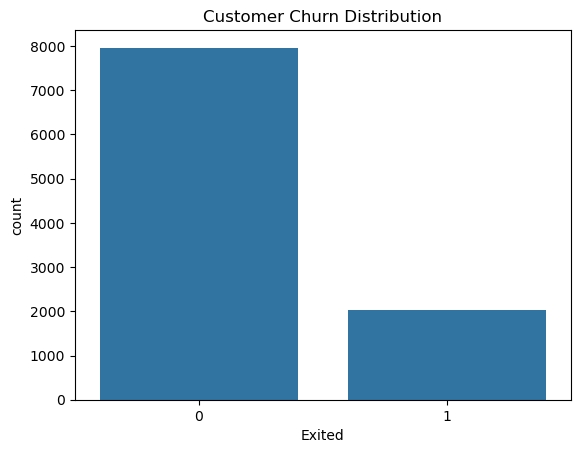

In [37]:
# Distribution of churned vs retained customers
sns.countplot(x="Exited",
              data=churn)

plt.title("Customer Churn Distribution")
plt.show()

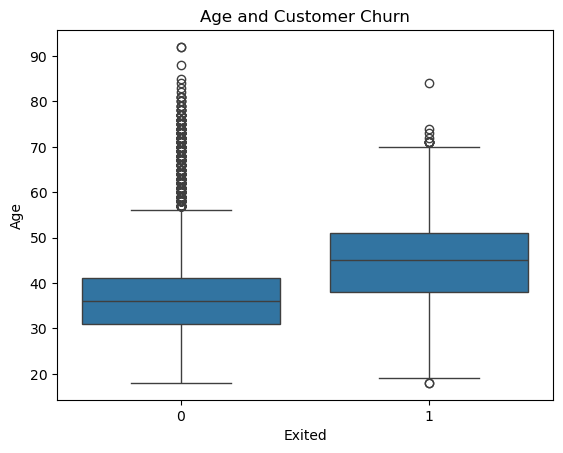

In [38]:
# Age vs Churn
sns.boxplot(x="Exited", 
            y="Age", 
            data=churn)

plt.title("Age and Customer Churn")
plt.show()

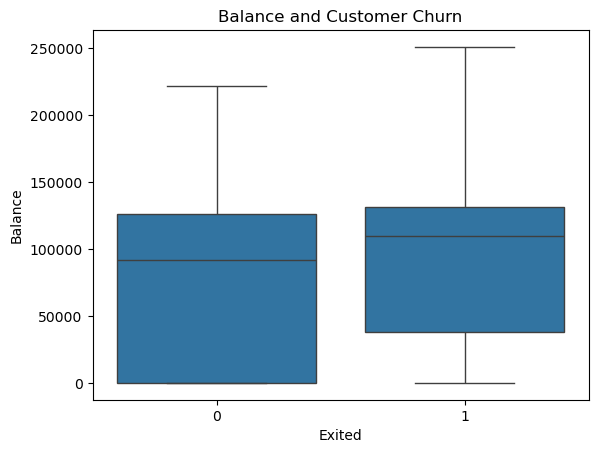

In [39]:
# Balance vs Churn
sns.boxplot(x="Exited", 
            y="Balance", 
            data=churn)

plt.title("Balance and Customer Churn")
plt.show()

## Model Training and Testing

In [40]:
# Define predictors and target
X = churn.drop("Exited", axis=1)

y = churn["Exited"]

In [41]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)

In [42]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [43]:
# Create model
model = RandomForestClassifier(random_state=42)

In [44]:
# Train model
model.fit(X_train, 
          y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
# Predictions 
predictions = model.predict(X_test)

## Evaluation Metrics

In [46]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, 
                          predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8665


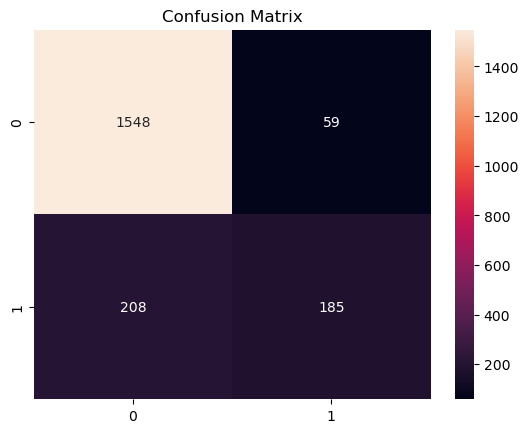

In [47]:
# Confusion Matrix 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,
                      predictions)

sns.heatmap(cm,
            annot=True,
            fmt="d")

plt.title("Confusion Matrix")
plt.show()

## Feature Importance Analysis

In [48]:
# Extract feature importance 
importance = pd.DataFrame({"Feature": X.columns,
                           "Importance": model.feature_importances_})

In [49]:
# Sort features 
importance = importance.sort_values(by="Importance",
                                    ascending=False)

importance.head(10)

,Feature,Importance
1,Age,0.236922
7,EstimatedSalary,0.147558
0,CreditScore,0.143338
3,Balance,0.141612
4,NumOfProducts,0.131486
2,Tenure,0.082080
6,IsActiveMember,0.040725
8,Geography_Germany,0.026190
5,HasCrCard,0.018454
10,Gender_Male,0.018421


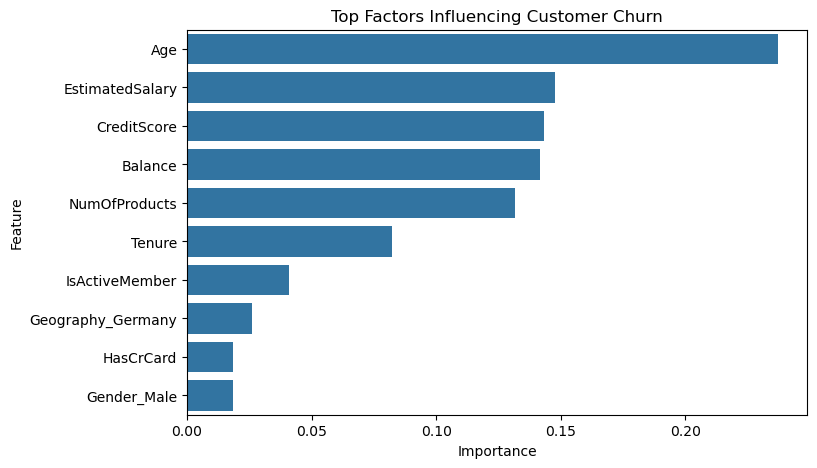

In [50]:
# Plot feature importance 
plt.figure(figsize=(8,5))

sns.barplot(data=importance.head(10),
            x="Importance",
            y="Feature")

plt.title("Top Factors Influencing Customer Churn")
plt.show()

## Conclusion and Key Insights
## Conclusion
A churn prediction model was developed to identify customers likely to leave the bank. Feature importance analysis helped determine which customer characteristics most strongly influence churn behavior.

## Key Insights
1) Churn Distribution
* The churn distribution indicates that retained customers significantly outnumber churned customers. This suggests a class imbalance in the dataset.

2) Age and Churn
* The age boxplot suggests that older customers may be more likely to churn than younger customers.
* Customer age appears to have a meaningful relationship with churn behavior.

3) Balance and Churn
* Customers with higher account balances appear more likely to leave the bank.
* Balance is therefore an important predictor of churn.

4) Feature Importance Analysis

From the feature importance chart:
* Age is among the strongest predictors.
* Balance contributes significantly to churn prediction.
* Customer activity and engagement variables also appear influential.
* Geography and gender may contribute, but their impact is generally smaller than behavioral or financial features.

5) Model Performance
* The confusion matrix indicates that the model successfully identified a large proportion of both churned and retained customers.
* The overall accuracy suggests that the model is effective for churn prediction.

## Business Insight
Banks should focus retention efforts on customers who are older, less engaged, or show characteristics associated with higher churn risk.